In [17]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the sgp set you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [18]:
sgp_df = pickle.load(open('sgp_set_resnet','rb')) 
print(sgp_df.shape)
print('Propotion of 1s: ', np.round(sgp_df.y_true.sum()/sgp_df.shape[0],2))
sgp_df.head() 

(40000, 3)
Propotion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990
3,0.0,0.0,0.999980
4,0.0,0.0,0.999816


In [19]:
delta = 0.005
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds
num_targets = 100

In [20]:
train_set = sgp_df.iloc[:3*int(len(sgp_df)/4)]
train_set = train_set.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set = sgp_df.iloc[3*int(len(sgp_df)/4):]

Plot lines config

In [21]:
lines_list_theta = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                    {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                    {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':"#8F7A1C",'style':'--'},
                    {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':"#0f770a",'style':'-'}]
lines_list_coverage = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#d51414','style':'-'},
                       {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#1d3ae2','style':'--'},
                       {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'train_coverage','x_axis_name':'Coverage','colour':'#8F7A1C','style':'--'},
                       {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#0f770a','style':'-'}]

## <font color = 'yellow'> 1. __0/1 risk__ 
Dichotomy search for upper bound

In [22]:
metric_targets=np.linspace(0.0001,0.02,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

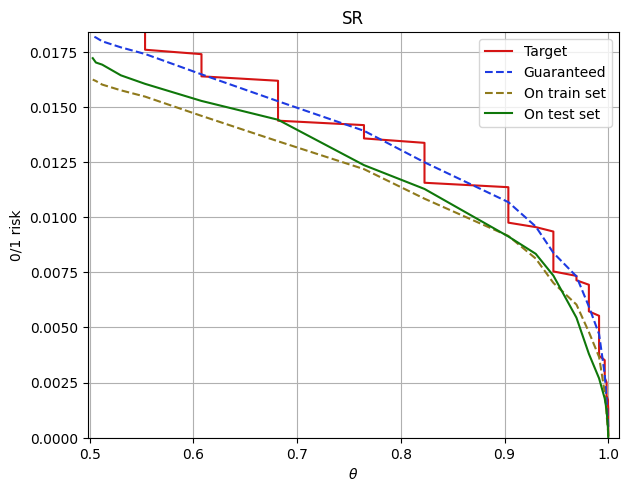

In [23]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

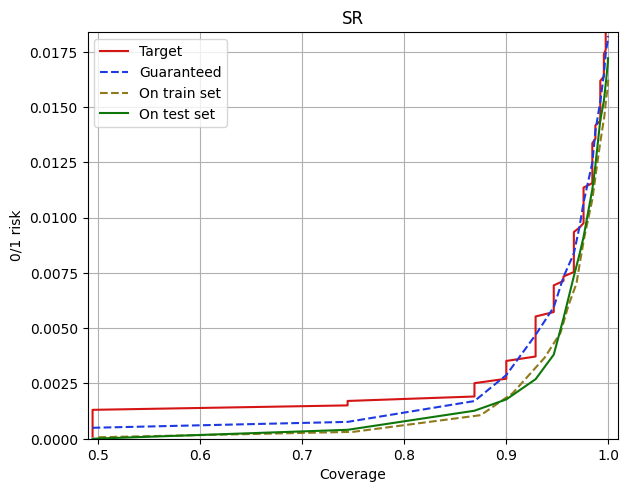

In [24]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

## <font color = 'yellow'> 2. __FP/FN risk__
Dichotomy search for upper bound

### <font color = 'orange'> 2.1. __FP risk__

In [25]:
metric_targets=np.linspace(0.0001,0.0035,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

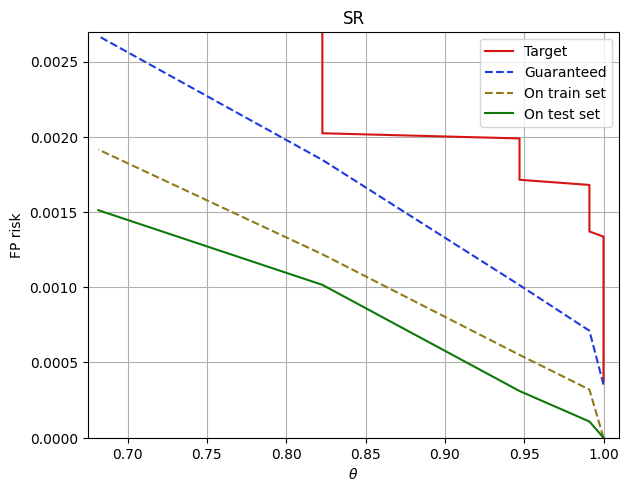

In [26]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho',
                         metric='FP')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

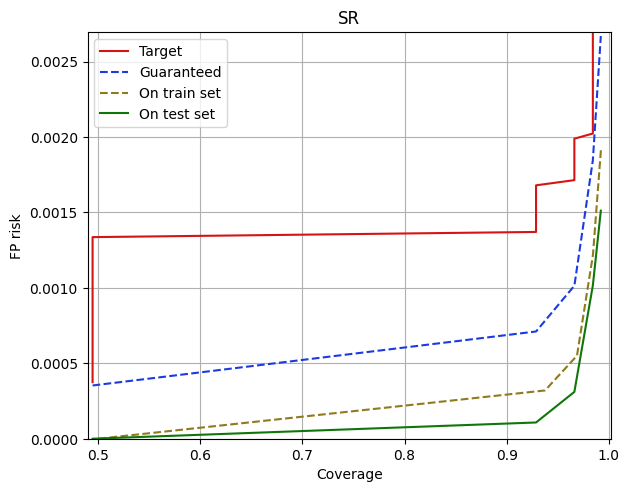

In [27]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 2.2. __FN risk__

In [28]:
metric_targets=np.linspace(0.0001,0.025,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

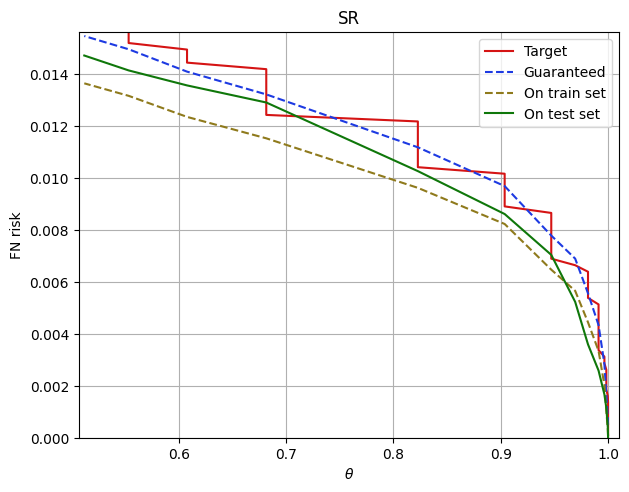

In [29]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho',
                         metric='FN')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

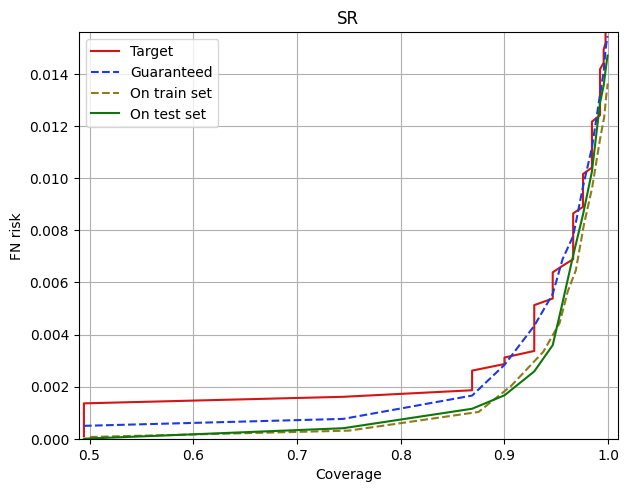

In [30]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

## <font color = 'yellow'> __3. Conditional metrics__

### <font color = 'orange'> 3.1. __FPR__

In [31]:
metric_targets=np.linspace(0.0001,0.0035,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

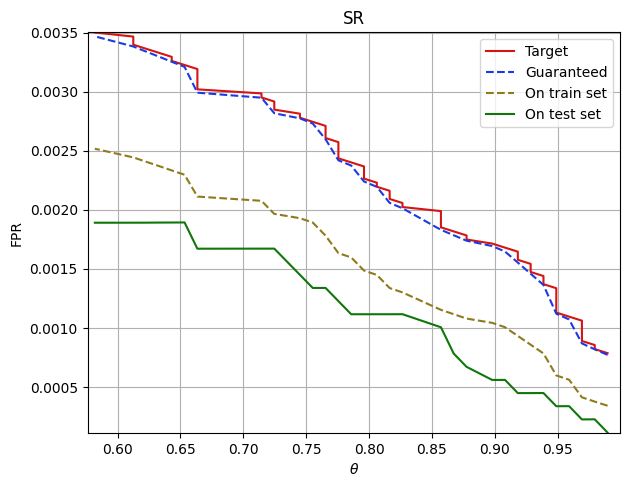

In [32]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='FPR')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

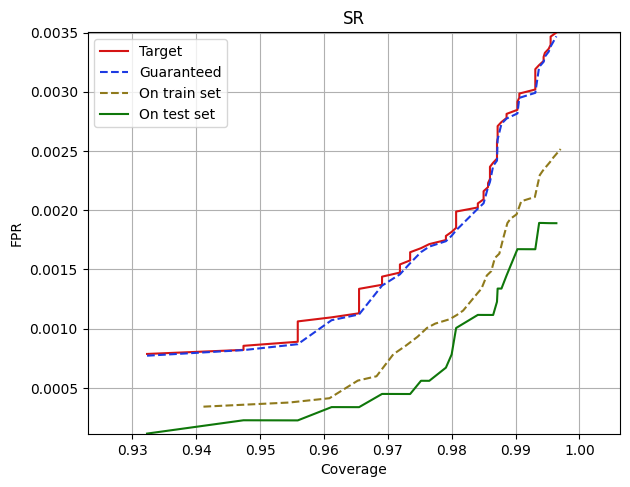

In [33]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 3.2. __FNR__

In [34]:
metric_targets=np.linspace(0.03,0.2,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

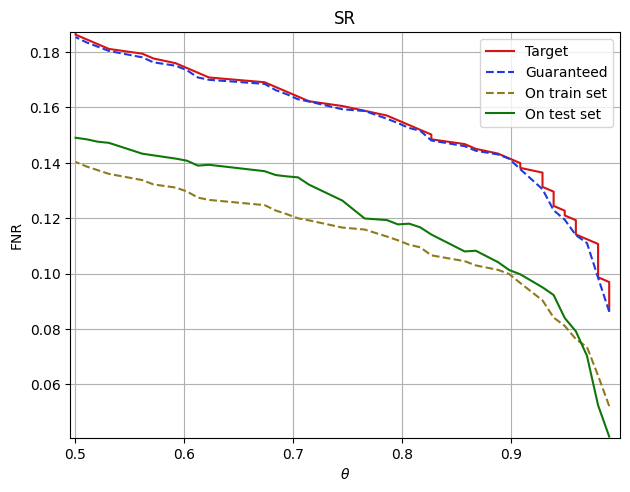

In [35]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='FNR')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

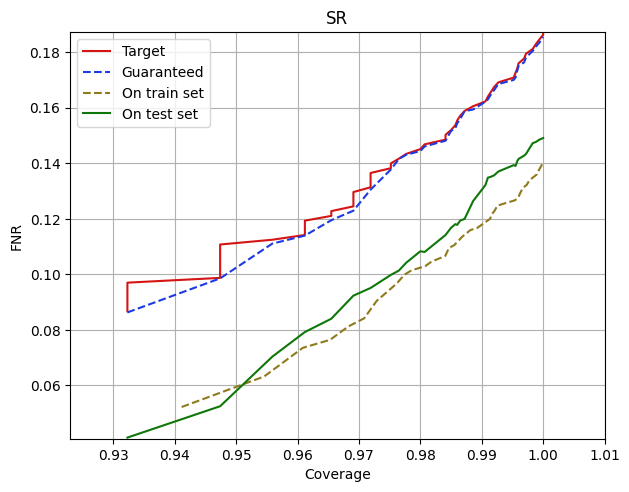

In [36]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 3.3. __PPV__

In [37]:
metric_targets=np.linspace(0.95,0.999,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

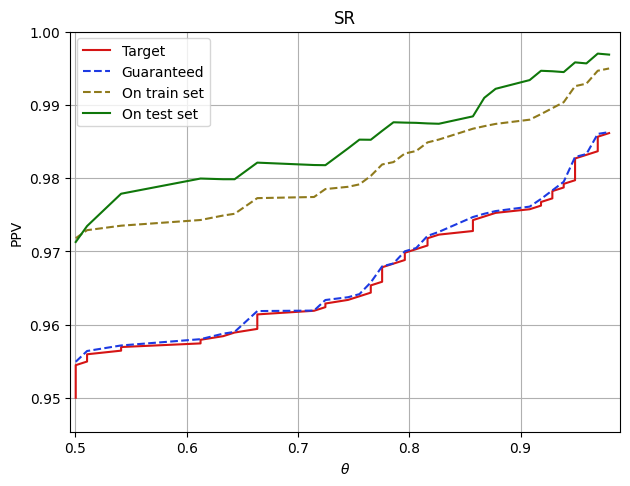

In [38]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='PPV')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

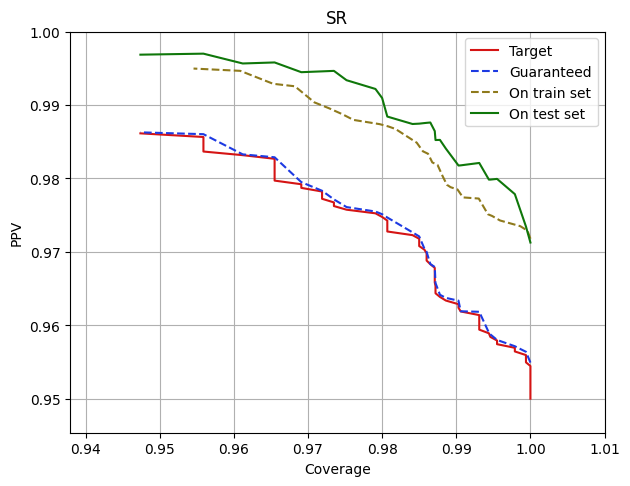

In [39]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

### <font color = 'orange'> 3.4. __SE__

In [40]:
metric_targets=np.linspace(0.84,0.96,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

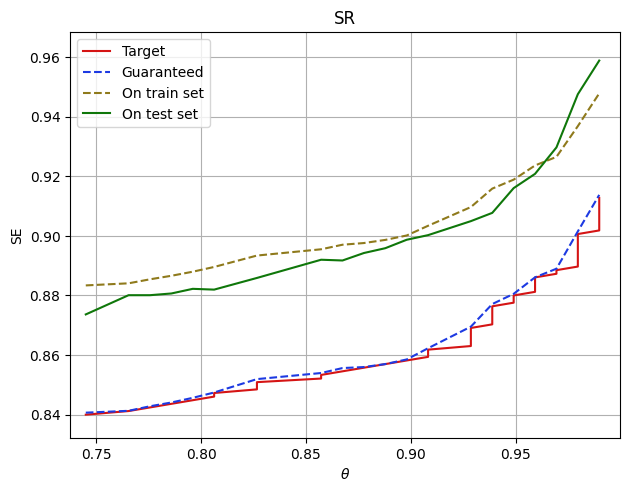

In [41]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='SE')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='SE', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

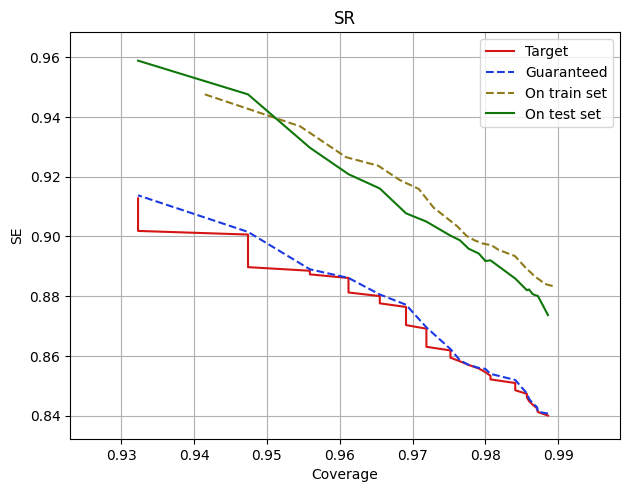

In [42]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

### <font color = 'orange'> 3.5. __SP__

In [43]:
metric_targets=np.linspace(0.99,0.9999,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

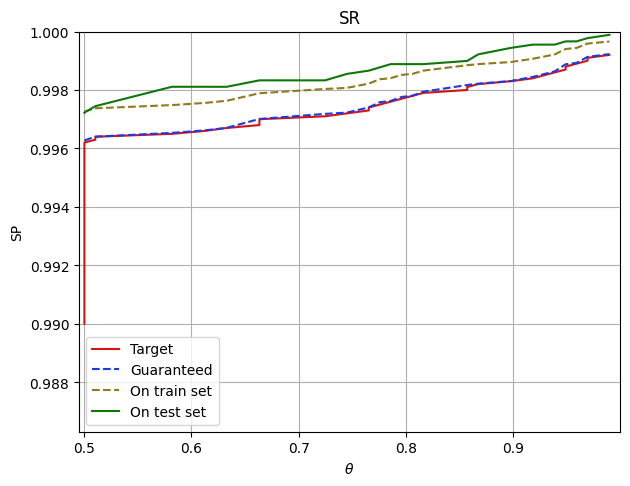

In [44]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='SP')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='SP', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

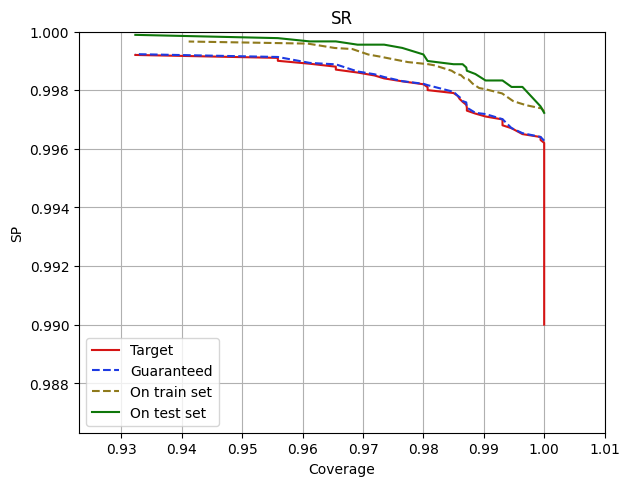

In [45]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')